In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [20]:
import numpy as np

In [2]:
#data loading / wczytywanie danych
surowe = pd.read_csv('data_ecommerce_customer_churn.csv')

In [3]:
surowe

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


In [24]:
#raw data info / info o surowych danych
surowe.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


In [26]:
#number of duplicates / liczba duplikatów
surowe.duplicated().sum()

np.int64(671)

In [27]:
print(f"Liczba wierszy przed usunięciem duplikatów: {len(surowe)}")

Liczba wierszy przed usunięciem duplikatów: 3941


In [4]:
dane = surowe.drop_duplicates()
print(f"Liczba wierszy po usunięciu duplikatów: {len(dane)}")

Liczba wierszy po usunięciu duplikatów: 3270


In [5]:
#nulls per column / liczba nulli dla każdej z kolumn
dane.isnull().sum()

Tenure                      160
WarehouseToHome             135
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64

In [6]:
#imputing nulls with median for numerical variables / uzupełnienie nulli medianą dla zmiennych numerycznych
dane['Tenure'] = dane['Tenure'].fillna(dane['Tenure'].median())
dane['WarehouseToHome'] = dane['WarehouseToHome'].fillna(
    dane['WarehouseToHome'].median()
)
dane['DaySinceLastOrder'] = dane['DaySinceLastOrder'].fillna(
    dane['DaySinceLastOrder'].median()
)

#verification / sprawdzenie
print(dane.isnull().sum())

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


In [7]:
#data type conversion / zmiana typów danych 
dane['Tenure'] = dane['Tenure'].astype('int64')
dane['DaySinceLastOrder'] = dane['DaySinceLastOrder'].astype('int64')

#verification / sprawdzenie
dane.info()

<class 'pandas.DataFrame'>
Index: 3270 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3270 non-null   int64  
 1   WarehouseToHome           3270 non-null   float64
 2   NumberOfDeviceRegistered  3270 non-null   int64  
 3   PreferedOrderCat          3270 non-null   str    
 4   SatisfactionScore         3270 non-null   int64  
 5   MaritalStatus             3270 non-null   str    
 6   NumberOfAddress           3270 non-null   int64  
 7   Complain                  3270 non-null   int64  
 8   DaySinceLastOrder         3270 non-null   int64  
 9   CashbackAmount            3270 non-null   float64
 10  Churn                     3270 non-null   int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 306.6 KB


In [8]:
dane['PreferedOrderCat'].value_counts()

PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64

In [9]:
dane['MaritalStatus'].value_counts()

MaritalStatus
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64

In [10]:
dane['SatisfactionScore'].value_counts()

SatisfactionScore
3    932
1    707
5    635
4    604
2    392
Name: count, dtype: int64

In [11]:
#descriptive statistics for numerical variables / statystyki opisowe dla zmiennych numerycznych
dane.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,3270.0,10.132110,8.440368,0.0,3.0000,9.000,15.0000,61.00
WarehouseToHome,3270.0,15.406728,8.404449,5.0,9.0000,13.000,20.0000,127.00
NumberOfDeviceRegistered,3270.0,3.676453,1.017390,1.0,3.0000,4.000,4.0000,6.00
SatisfactionScore,3270.0,3.020795,1.395113,1.0,2.0000,3.000,4.0000,5.00
NumberOfAddress,3270.0,4.222936,2.623195,1.0,2.0000,3.000,6.0000,22.00
Complain,3270.0,0.281651,0.449873,0.0,0.0000,0.000,1.0000,1.00
DaySinceLastOrder,3270.0,4.459939,3.609590,0.0,2.0000,3.000,7.0000,46.00
CashbackAmount,3270.0,177.417670,49.310647,0.0,145.8925,163.885,197.1375,324.99
Churn,3270.0,0.163303,0.369698,0.0,0.0000,0.000,0.0000,1.00


In [12]:
#churn rate / wskaźnik churnu
print(dane['Churn'].value_counts(normalize=True) * 100)

Churn
0    83.669725
1    16.330275
Name: proportion, dtype: float64


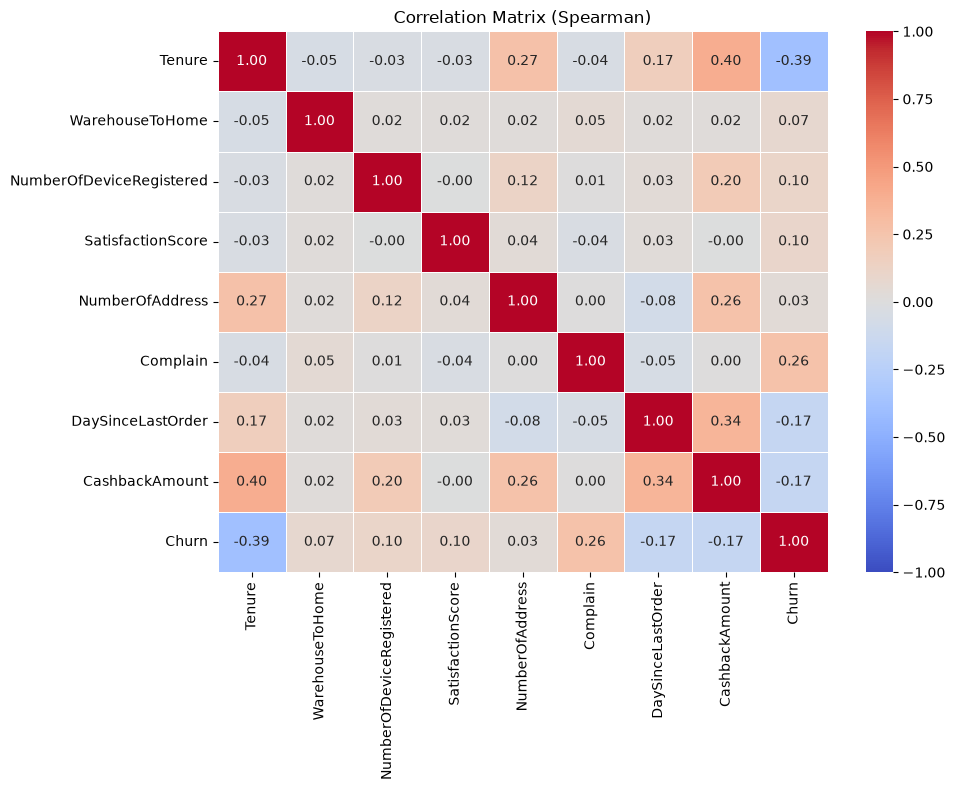

--- Correlation with Churn ---
Complain                    0.262278
NumberOfDeviceRegistered    0.104776
SatisfactionScore           0.097100
WarehouseToHome             0.070879
NumberOfAddress             0.033872
DaySinceLastOrder          -0.167629
CashbackAmount             -0.170794
Tenure                     -0.386566
Name: Churn, dtype: float64


In [38]:
#correlations / korelacje
kolumny_numeryczne = dane.select_dtypes(include=[np.number]).columns

macierz_korelacji = dane[kolumny_numeryczne].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    macierz_korelacji,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

korelacja_churn = (
    macierz_korelacji['Churn']
    .drop('Churn')
    .sort_values(ascending=False)
)
print('--- Correlation with Churn ---')
print(korelacja_churn)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#exploratory data visualisations / wykresy dla przejrzenia danych

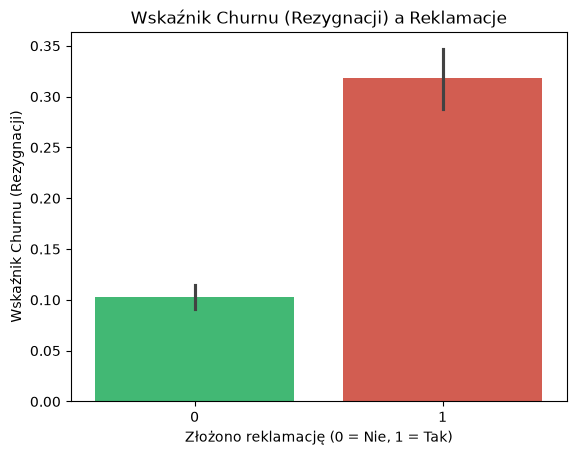

In [14]:
sns.barplot(
    data=dane,
    x='Complain',
    y='Churn',
    hue='Complain',
    palette=['#2ecc71', '#e74c3c'],  # Zielony dla braku reklamacji, czerwony dla reklamacji
    legend=False,
)

plt.title('Wskaźnik Churnu (Rezygnacji) a Reklamacje')
plt.xlabel('Złożono reklamację (0 = Nie, 1 = Tak)')
plt.ylabel('Wskaźnik Churnu (Rezygnacji)')
plt.show()

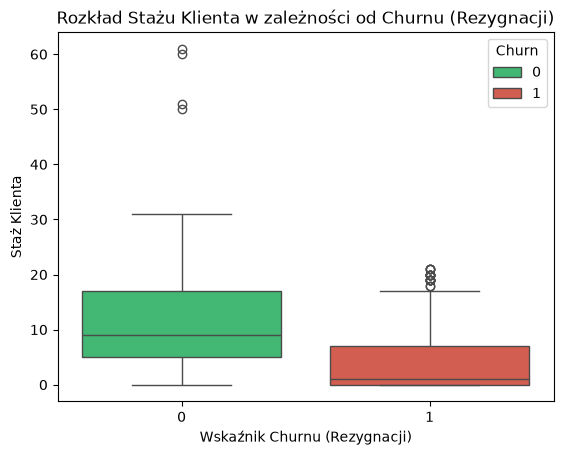

In [15]:
sns.boxplot(data=dane, x='Churn', y='Tenure', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Rozkład Stażu Klienta w zależności od Churnu (Rezygnacji)')
plt.xlabel('Wskaźnik Churnu (Rezygnacji)')
plt.ylabel('Staż Klienta')
plt.show()

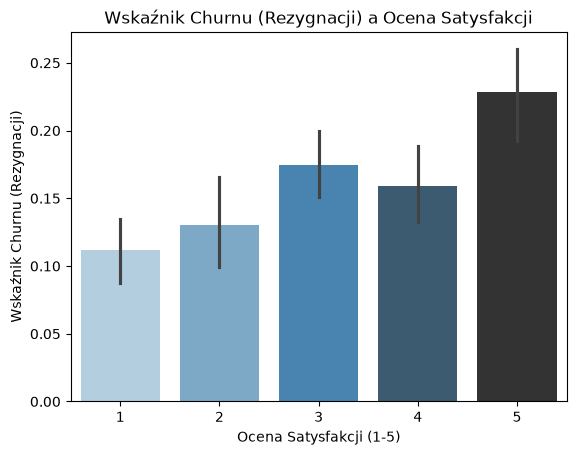

In [16]:
sns.barplot(
    data=dane,
    x='SatisfactionScore',
    y='Churn',
    hue='SatisfactionScore',
    palette="Blues_d",  
    legend=False,
)

plt.title('Wskaźnik Churnu (Rezygnacji) a Ocena Satysfakcji')
plt.xlabel('Ocena Satysfakcji (1-5)')
plt.ylabel('Wskaźnik Churnu (Rezygnacji)')
plt.show()

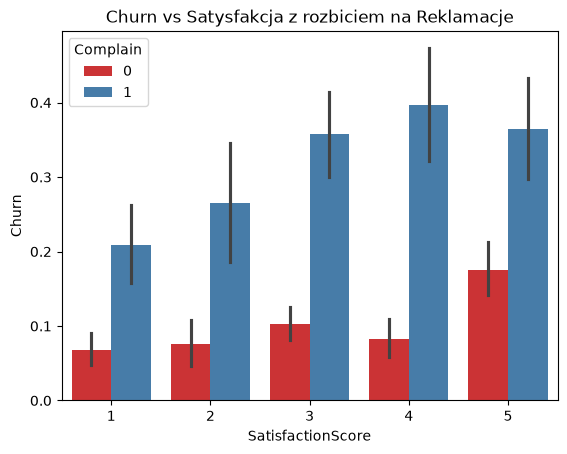

In [17]:
sns.barplot(
    data=dane,
    x='SatisfactionScore',
    y='Churn',
    hue='Complain',
    palette='Set1',
)
plt.title('Churn vs Satysfakcja z rozbiciem na Reklamacje')
plt.show()

In [18]:
dane.groupby('SatisfactionScore')['Tenure'].mean()

SatisfactionScore
1    10.403112
2     9.989796
3    10.311159
4    10.481788
5     9.322835
Name: Tenure, dtype: float64

In [19]:
#saving cleaned data / zapisywanie wyczyszczonych danych
dane.to_csv('dane_e_commerce_clean.csv', index=False)

In [ ]:
#prediction / predykcja

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
#feature (X) and target (y) definition / wskazanie zmiennych (X) oraz zmiennej docelowej (y)
X = dane.drop(columns=['Churn'])
y = dane['Churn']

#categorical encoding (One-Hot Encoding) / kodowanie zmiennych kategorycznych (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

#train-test split (80/20) / podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

#feature scaling / skalowanie cech numerycznych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Liczba cech po kodowaniu: {X_encoded.shape[1]}")
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]} próbek")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} próbek")

Liczba cech po kodowaniu: 15
Rozmiar zbioru treningowego: 2616 próbek
Rozmiar zbioru testowego: 654 próbek


In [26]:
#random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#model training with class imbalance handling / trening modelu z obsługą nierównowagi klas
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

#prediction on test set / predykcja na zbiorze testowym
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

#model performance evaluation / ewaluacja wyników
print("--- RAPORT KLASYFIKACJI (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

#confusion matrix / macierz pomyłek
print("\n--- MACIERZ POMYŁEK ---")
print(confusion_matrix(y_test, y_pred_rf))

--- RAPORT KLASYFIKACJI (Random Forest) ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       547
           1       0.70      0.83      0.76       107

    accuracy                           0.91       654
   macro avg       0.83      0.88      0.85       654
weighted avg       0.92      0.91      0.92       654

ROC-AUC Score: 0.9552

--- MACIERZ POMYŁEK ---
[[508  39]
 [ 18  89]]


C:\Users\natal\AppData\Local\Temp\ipykernel_52664\575895716.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


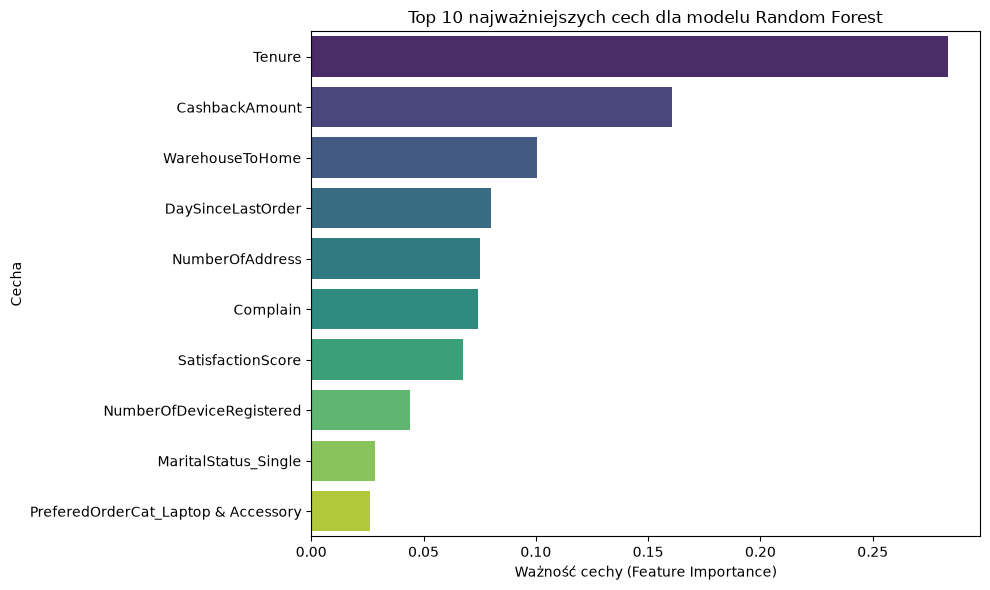

                                Feature  Importance
0                                Tenure    0.283576
7                        CashbackAmount    0.160764
1                       WarehouseToHome    0.100319
6                     DaySinceLastOrder    0.079894
4                       NumberOfAddress    0.075102
5                              Complain    0.074299
3                     SatisfactionScore    0.067465
2              NumberOfDeviceRegistered    0.044163
14                 MaritalStatus_Single    0.028430
9   PreferedOrderCat_Laptop & Accessory    0.026178


In [35]:
#extracting feature importance / pobranie ważności zmiennych z modelu
v_importance = rf_model.feature_importances_
feature_names = X_encoded.columns

#creating df & sorting / utworzenie df i sortowanie
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': v_importance
}).sort_values(by='Importance', ascending=False)

#top 10 feature importance plot / wykres top 10 zmiennych
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 najważniejszych cech dla modelu Random Forest')
plt.xlabel('Ważność cechy (Feature Importance)')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

print(df_importance.head(10))

In [33]:
#xgboost

from xgboost import XGBClassifier

#model training / trening modelu
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # obsługa nierównowagi
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

#prediction / predykcja
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

#evaluation / wyniki
print("--- RAPORT KLASYFIKACJI (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

#confusion matrix / macierz pomyłek
print("\n--- MACIERZ POMYŁEK ---")
print(confusion_matrix(y_test, y_pred_xgb))

--- RAPORT KLASYFIKACJI (XGBoost) ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       547
           1       0.71      0.89      0.79       107

    accuracy                           0.92       654
   macro avg       0.85      0.91      0.87       654
weighted avg       0.93      0.92      0.93       654

ROC-AUC Score: 0.9636

--- MACIERZ POMYŁEK ---
[[509  38]
 [ 12  95]]


C:\Users\natal\AppData\Local\Temp\ipykernel_52664\2981089266.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


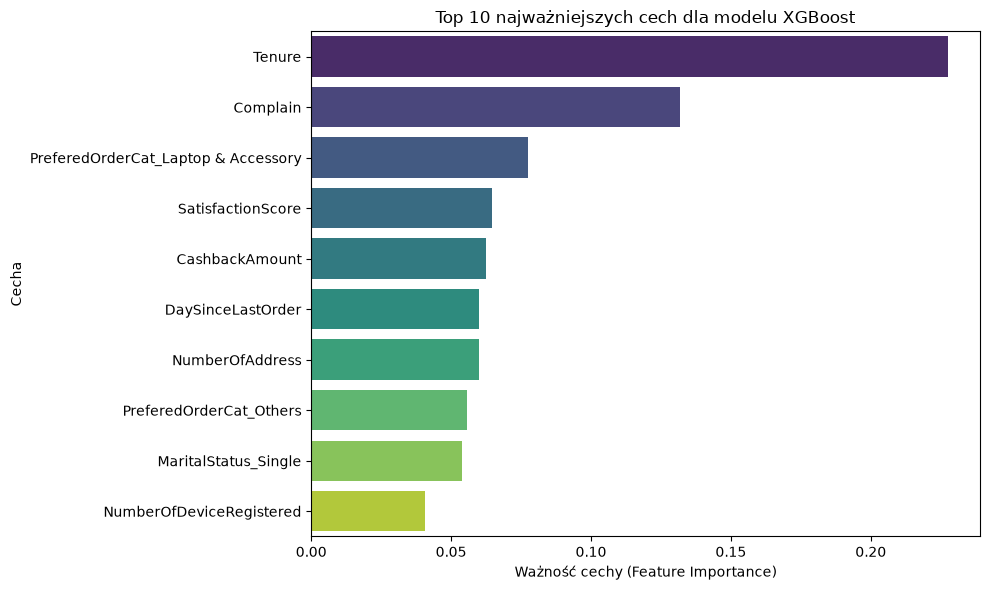

                                Feature  Importance
0                                Tenure    0.227658
5                              Complain    0.131638
9   PreferedOrderCat_Laptop & Accessory    0.077602
3                     SatisfactionScore    0.064578
7                        CashbackAmount    0.062378
6                     DaySinceLastOrder    0.060025
4                       NumberOfAddress    0.059936
12              PreferedOrderCat_Others    0.055611
14                 MaritalStatus_Single    0.053950
2              NumberOfDeviceRegistered    0.040747


In [37]:
#extracting feature importance / pobranie ważności zmiennych z modelu 
v_importance_xgb = xgb_model.feature_importances_
feature_names = X_encoded.columns

#creating df & sorting / utworzenie df i sortowanie
df_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': v_importance_xgb
}).sort_values(by='Importance', ascending=False)

#top 10 feature importance plot / wykres top 10 zmiennych
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance_xgb.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 najważniejszych cech dla modelu XGBoost')
plt.xlabel('Ważność cechy (Feature Importance)')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

print(df_importance_xgb.head(10))